#Dataset Exploration

1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Define dataset path

In [2]:
DATASET_ZIP = "/content/drive/MyDrive/datasets/SmallMinesDS.zip"
EXTRACT_PATH = "/content/SmallMinesDS"

3. Unzip dataset

In [3]:
import zipfile
import os

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted!")

Dataset extracted!


4. Set main dataset directory

In [4]:
DATASET_PATH = "/content/SmallMinesDS/SmallMinesDS"

In [5]:
import os

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    print("sample files:", files[:2])
    print("-"*50)

/content/SmallMinesDS/SmallMinesDS
sample files: []
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2016
sample files: []
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2016/MASK
sample files: ['MASK_GH_1210_2016.tif', 'MASK_GH_0988_2016.tif']
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2016/IMAGE
sample files: ['IMG_GH_0367_2016.tif', 'IMG_GH_0293_2016.tif']
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2022
sample files: []
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2022/MASK
sample files: ['MASK_GH_0906_2022.tif', 'MASK_GH_0747_2022.tif']
--------------------------------------------------
/content/SmallMinesDS/SmallMinesDS/2022/IMAGE
sample files: ['IMG_GH_1378_2022.tif', 'IMG_GH_1468_2022.tif']
--------------------------------------------------


5. Install required library for .tif

In [6]:
!pip install rasterio

6. Load a single .tif image

In [7]:
import rasterio
import numpy as np

def read_tif(path):
    with rasterio.open(path) as src:
        img = src.read()  # (bands, H, W)
    return img

7. Pick one sample image and mask

In [8]:
import glob

image_files = glob.glob(DATASET_PATH + "/2016/IMAGE/*.tif")
mask_files  = glob.glob(DATASET_PATH + "/2016/MASK/*.tif")

print("Images:", len(image_files))
print("Masks:", len(mask_files))

sample_img_path = image_files[0]
sample_mask_path = mask_files[0]

Images: 2135
Masks: 2135


8. Load the data

In [9]:
image = read_tif(sample_img_path)
mask = read_tif(sample_mask_path)

print("Image shape:", image.shape)  # (13, 128, 128)
print("Mask shape:", mask.shape)    # (1, 128, 128)

Image shape: (13, 128, 128)
Mask shape: (1, 128, 128)


9. Visualize one band

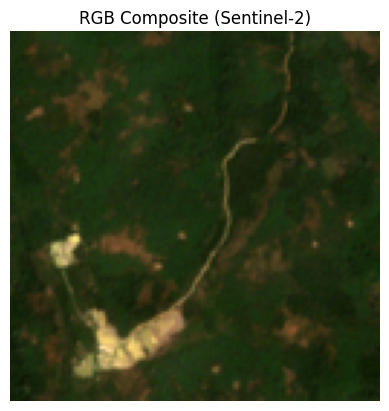

In [10]:
import matplotlib.pyplot as plt

# Sentinel-2 bands:
# 0 = blue, 1 = green, 2 = red

rgb = np.stack([image[2], image[1], image[0]], axis=-1)

# normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

plt.imshow(rgb)
plt.title("RGB Composite (Sentinel-2)")
plt.axis("off")
plt.show()

10. Visualize mask

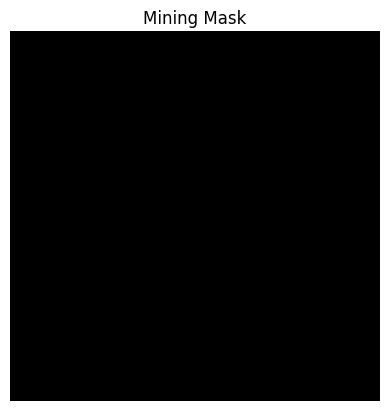

In [11]:
plt.imshow(mask[0], cmap="gray")
plt.title("Mining Mask")
plt.axis("off")
plt.show()